# Creating an Arbitrary Index from Nasdaq Company Tickers

The goal of this project is to create an arbitrary stock index based on Nasdaq-listed companies whose ticker symbols follow a specific rule.

For example, the **Y Index** contains all eligible Nasdaq-listed companies whose ticker starts with the letter **Y**.

The objective is not only to create the index, but also to build a reproducible pipeline that:

1. Downloads the universe of Nasdaq-listed securities.
2. Identifies real operating companies.
3. Removes financial instruments that are not suitable for an equity index.
4. Applies eligibility rules similar to professional index providers.
5. Calculates index constituents and weights.
6. Performs exploratory data analysis (EDA) on the resulting index.

---

## 1. Data Sources

### SEC Company Tickers

The SEC provides a list of companies that file reports with the U.S. Securities and Exchange Commission.

Source:

https://www.sec.gov/files/company_tickers.json

This dataset contains:

- Company name
- Ticker symbol
- SEC CIK identifier

Example:

```json
{
"ticker": "AAPL",
"title": "Apple Inc.",
"cik_str": 320193
}
```

The SEC dataset is useful because it represents **actual reporting companies**, unlike exchange symbol lists that may contain many financial products.

---

### Nasdaq Listed Securities

Source:

https://ftp.nasdaqtrader.com/SymbolDirectory/nasdaqlisted.txt

This file contains all securities listed on Nasdaq.

It includes:

- Common stocks
- ADRs
- ETFs
- Warrants
- Rights
- Units
- Preferred shares
- Other financial instruments

The Nasdaq dataset is required because it provides the official universe of securities traded on Nasdaq.

### Data location

Both files are in the `/data` directory.

---

## 2. Building the Company Universe

We combine the SEC and Nasdaq datasets to create a clean universe of companies.

The process is:


Nasdaq Listed Securities --> Remove ETFs and test securities --> Join with SEC reporting companies -- >
Remove non-equity securities --> Remove SPACs --> Apply company age filters (remove less than 1 year)

This gives us the universe where we can select our companies for the index.

---

## 3. Security Filtering Rules

We exclude the following securities because they do not represent ordinary company ownership.

- ETFs
- Test issues
- NextShares
- Warrants
- Rights
- Units
- Preferred shares
- Bonds and notes
- Other derivative instruments

Examples:

| Symbol | Type | Action |
|---|---|---|
| AAPL | Common stock | Keep |
| YICC | Common stock | Keep |
| YICCU | Unit | Remove |
| YICCW | Warrant | Remove |

---

## 4. Company Eligibility Rules

We apply other filters to create a more realistic index universe:

### Remove SPACs

We remove Special Purpose Acquisition Companies.

Examples of excluded names:

- Acquisition Corp
- Acquisition Holdings
- Blank Check Company

The reason is that these entities do not represent mature operating businesses.

---

### Minimum Company Age

We exclude companies younger than one year.

This avoids including:

- Recently created SPACs
- Very recent IPOs
- **Companies without sufficient trading history**

---

## 5. Creating the Letter-Based Index Universe

After cleaning the Nasdaq company universe, we group companies by ticker letter.

- A Index
- J Index
- Y Index
- Any other ticker-based universe

## GOAL: Find the Most Underrepresented Letter in the tickers, and Create an Index Based on it

In [ ]:
from src.universe import build_company_universe
from src.index import (
    companies_with_letter,
    ticker_letter_counts,
    least_common_letters,
    build_j_index_constituents,
    calculate_j_index,
    download_index_prices,
)
from src.utils import save_parquet_cache
from openbb import obb
import matplotlib.pyplot as plt

obb.user.preferences.output_type = "dataframe"

In [2]:
universe = build_company_universe(
    "data/sec.json",
    "data/nasdaqlisted.txt",
)

In [3]:
counts = ticker_letter_counts(universe)

print(counts)

least_common_letters(universe)

   letter  companies
0       J         40
1       Q         52
2       Z         91
3       U        177
4       W        178
5       Y        192
6       K        229
7       V        238
8       H        247
9       F        281
10      X        301
11      G        339
12      D        365
13      P        392
14      O        430
15      B        438
16      E        446
17      M        458
18      I        525
19      L        538
20      N        602
21      S        657
22      R        658
23      C        660
24      A        661
25      T        666


,letter,companies
0,J,40
1,Q,52
2,Z,91
3,U,177
4,W,178
5,Y,192
6,K,229
7,V,238
8,H,247
9,F,281


In [4]:
j_index = companies_with_letter(universe, "J")

j_index

,Symbol,Security Name,Market Category,Test Issue,Financial Status,Round Lot Size,ETF,NextShares,CIK,Company
0,AIRJ,AirJoule Technologies Corporation - Class A Co...,S,N,N,100.0,N,N,1855474,AirJoule Technologies Corp.
1,BJDX,"Bluejay Diagnostics, Inc. - Common Stock",S,N,N,100.0,N,N,1704287,"Bluejay Diagnostics, Inc."
2,BJRI,"BJ's Restaurants, Inc. - Common Stock",Q,N,N,100.0,N,N,1013488,BJs RESTAURANTS INC
3,BOTJ,"Bank of the James Financial Group, Inc. - Comm...",S,N,N,100.0,N,N,1275101,BANK OF THE JAMES FINANCIAL GROUP INC
4,CJMB,Callan JMB Inc. - Common Stock,S,N,D,100.0,N,N,2032545,CALLAN JMB INC.
5,DJCO,Daily Journal Corp. (S.C.) - Common Stock,S,N,N,40.0,N,N,783412,DAILY JOURNAL CORP
6,DJT,Trump Media & Technology Group Corp. - Common ...,G,N,N,100.0,N,N,1849635,Trump Media & Technology Group Corp.
7,EJH,E-Home Household Service Holdings Limited - Or...,S,N,D,100.0,N,N,1769768,E-Home Household Service Holdings Ltd
8,INTJ,Intelligent Group Limited - Class A Ordinary S...,S,N,N,100.0,N,N,1916416,Intelligent Group Ltd
9,JACK,Jack In The Box Inc. - Common Stock,Q,N,N,100.0,N,N,807882,JACK IN THE BOX INC


In [5]:
save_parquet_cache(j_index, "data/j_index.parquet")

## Retrieving more data for the J Index

The letter that's more under-represented in the index is the letter J. This allows us to create the J Index, which has 40 companies in it.

Next, we will create a dataframe with some extra information about these companies (market capitalization and size, and sector). With this extra data, we'll be able to do some initial EDA explorations.

In [6]:
j_index_constituents = build_j_index_constituents(j_index)

j_index_constituents

,Symbol,Company,Sector,MarketCap,Weight,Size,Currency,Country,SIC,SIC_Description
0,JKHY,JACK HENRY & ASSOCIATES INC,Technology,10698826752,0.525998,Large Cap,USD,United States,7373,Services-Computer Integrated Systems Design
1,DJT,Trump Media & Technology Group Corp.,Communication Services,2370724864,0.116554,Mid Cap,USD,United States,7370,"Services-Computer Programming, Data Processing..."
2,JJSF,J&J SNACK FOODS CORP,Consumer Defensive,1433511168,0.070477,Small Cap,USD,United States,2052,Cookies & Crackers
3,BJRI,BJs RESTAURANTS INC,Consumer Cyclical,1405191552,0.069085,Small Cap,USD,United States,5812,Retail-Eating Places
4,RJET,REPUBLIC AIRWAYS HOLDINGS INC.,Industrials,809681664,0.039807,Small Cap,USD,United States,4512,"Air Transportation, Scheduled"
5,DJCO,DAILY JOURNAL CORP,Technology,792327872,0.038954,Small Cap,USD,United States,2711,Newspapers: Publishing or Publishing & Printing
6,JOUT,JOHNSON OUTDOORS INC,Consumer Cyclical,481731104,0.023684,Small Cap,USD,United States,3949,"Sporting & Athletic Goods, NEC"
7,JMSB,"John Marshall Bancorp, Inc.",Financial Services,315267072,0.015500,Small Cap,USD,United States,6022,State Commercial Banks
8,AIRJ,AirJoule Technologies Corp.,Industrials,301910464,0.014843,Small Cap,USD,United States,3585,Air-Cond & Warm Air Heatg Equip & Comm & Indl ...
9,JACK,JACK IN THE BOX INC,Consumer Cyclical,277521120,0.013644,Micro Cap,USD,United States,5812,Retail-Eating Places


## EDA: J Index Constituents

With the 40 companies enriched with market data, we can now explore the composition of the index.

In [7]:
from great_tables import GT, loc
from great_tables.style import css

gt_constituents = (
    GT(
        j_index_constituents[
            ["Symbol", "Company", "Sector", "MarketCap", "Weight", "Size", "Country"]
        ]
    )
    .fmt_number(columns="MarketCap", decimals=0, sep_mark=",")
    .fmt_percent(columns="Weight", decimals=1)
    .cols_align(align="center", columns=["Symbol", "Sector", "Size", "Country"])
    .cols_label(
        MarketCap="Market Cap ($)",
        Weight="Weight (%)",
        Country="Country",
    )
    .tab_header(
        title="J Index Constituents",
        subtitle="Nasdaq companies with the letter J in their ticker",
    )
    .opt_row_striping()
    .tab_options(row_striping_background_color="#f2f2f2")
)

max_weight = j_index_constituents["Weight"].max()

for idx, weight in enumerate(j_index_constituents["Weight"]):
    pct = weight / max_weight * 100

    gt_constituents = gt_constituents.tab_style(
        style=css(
            f"background: linear-gradient(90deg, #a5d6a7 {pct:.1f}%, transparent {pct:.1f}%)"
        ),
        locations=loc.body(rows=[idx], columns="Weight"),
    )

gt_constituents.gtsave("img/j_index_constituents.png")
gt_constituents


GT(_tbl_data=   Symbol                                Company                  Sector  \
0    JKHY            JACK HENRY & ASSOCIATES INC              Technology   
1     DJT   Trump Media & Technology Group Corp.  Communication Services   
2    JJSF                   J&J SNACK FOODS CORP      Consumer Defensive   
3    BJRI                    BJs RESTAURANTS INC       Consumer Cyclical   
4    RJET         REPUBLIC AIRWAYS HOLDINGS INC.             Industrials   
5    DJCO                     DAILY JOURNAL CORP              Technology   
6    JOUT                   JOHNSON OUTDOORS INC       Consumer Cyclical   
7    JMSB            John Marshall Bancorp, Inc.      Financial Services   
8    AIRJ            AirJoule Technologies Corp.             Industrials   
9    JACK                    JACK IN THE BOX INC       Consumer Cyclical   
10   JDZG                              JIADE Ltd      Consumer Defensive   
11   JRVR       James River Group Holdings, Inc.      Financial Services   
12   JLHL                     Julong Holding Ltd             Industrials   
13   BOTJ  BANK OF THE JAMES FINANCIAL GROUP INC      Financial Services   
14   JYNT                             JOINT Corp              Healthcare   
15    ZJK               ZJK Industrial Co., Ltd.             Industrials   
16    JXG               JX Luxventure Group Inc.       Consumer Cyclical   
17    JFB              JFB Construction Holdings             Real Estate   
18   JRSH             Jerash Holdings (US), Inc.       Consumer Cyclical   
19   TJGC                         TJGC GROUP Ltd  Communication Services   
20     SJ                  Scienjoy Holding Corp  Communication Services   
21   JSPR              Jasper Therapeutics, Inc.              Healthcare   
22     JL                       J-Long Group Ltd       Consumer Cyclical   
23    JVA                  COFFEE HOLDING CO INC      Consumer Defensive   
24   ZJYL         Jin Medical International Ltd.              Healthcare   
25   CJMB                        CALLAN JMB INC.             Industrials   
26   JCTC          JEWETT CAMERON TRADING CO LTD         Basic Materials   
27    JYD             Jayud Global Logistics Ltd             Industrials   
28   YHGJ                 YUNHONG GREEN CTI LTD.       Consumer Cyclical   
29   JCSE              JE Cleantech Holdings Ltd             Industrials   
30     YJ                             Yunji Inc.       Consumer Cyclical   
31    EJH  E-Home Household Service Holdings Ltd       Consumer Cyclical   
32   JUNS            JUPITER NEUROSCIENCES, INC.              Healthcare   
33   INTJ                  Intelligent Group Ltd             Industrials   
34    JEM               707 Cayman Holdings Ltd.       Consumer Cyclical   
35   JWEL                     Jowell Global Ltd.       Consumer Cyclical   
36   JTAI                            Jet.AI Inc.              Technology   
37   JZXN                   Jiuzi Holdings, Inc.       Consumer Cyclical   
38   BJDX              Bluejay Diagnostics, Inc.              Healthcare   
39   LBGJ        Li Bang International Corp Inc.             Industrials   

      MarketCap    Weight       Size        Country  
0   10698826752  0.525998  Large Cap  United States  
1    2370724864  0.116554    Mid Cap  United States  
2    1433511168  0.070477  Small Cap  United States  
3    1405191552  0.069085  Small Cap  United States  
4     809681664  0.039807  Small Cap  United States  
5     792327872  0.038954  Small Cap  United States  
6     481731104  0.023684  Small Cap  United States  
7     315267072  0.015500  Small Cap  United States  
8     301910464  0.014843  Small Cap  United States  
9     277521120  0.013644  Micro Cap  United States  
10    274000000  0.013471  Micro Cap          China  
11    217775600  0.010707  Micro Cap  United States  
12    130407680  0.006411  Micro Cap  United States  
13    122352120  0.006015  Micro Cap  United States  
14    119032560  0.005852  Micro Cap  United States  
15    

### Size Distribution

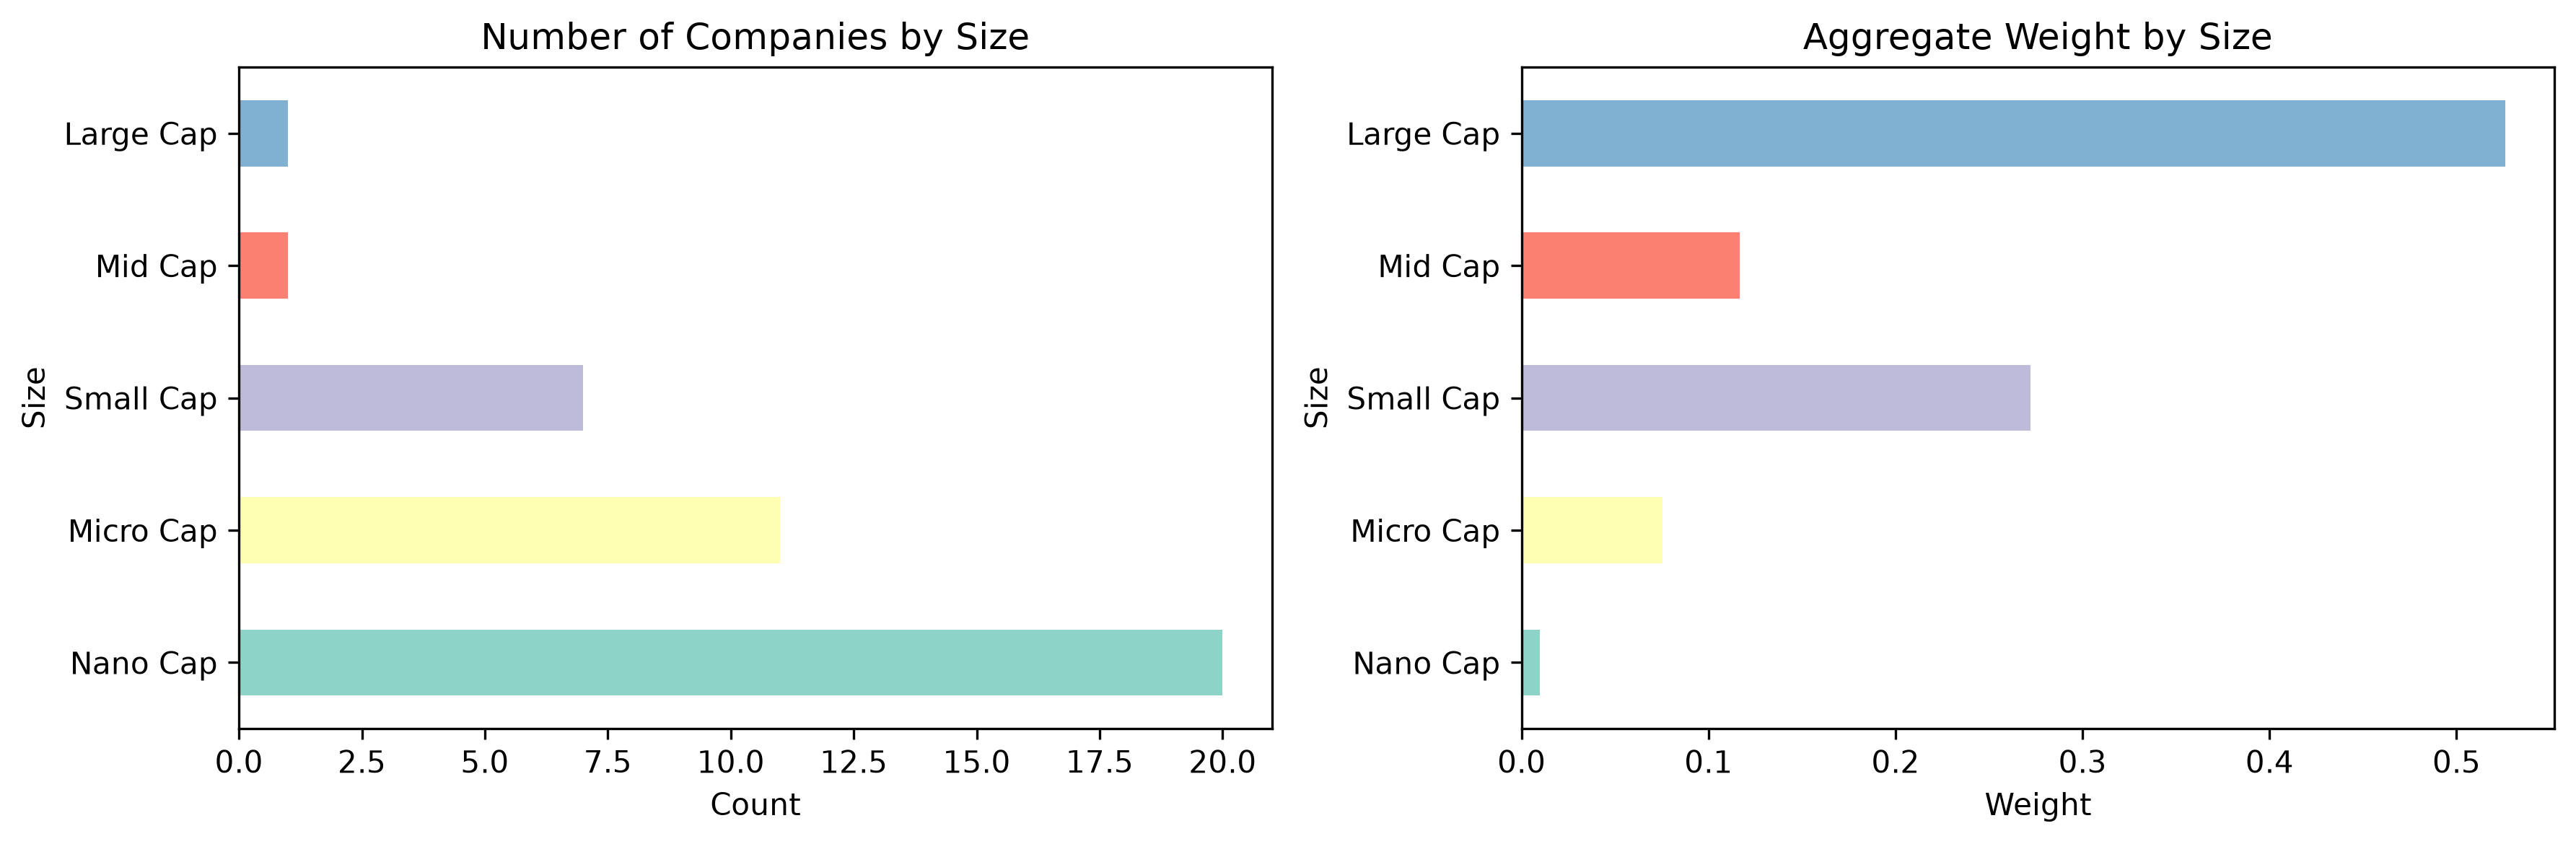

Size
Nano Cap     20
Micro Cap    11
Small Cap     7
Mid Cap       1
Large Cap     1
Name: count, dtype: int64

Weight by size:
Size
Large Cap    52.60%
Small Cap    27.24%
Mid Cap      11.66%
Micro Cap     7.53%
Nano Cap      0.98%
Name: Weight, dtype: str


In [8]:
import matplotlib.pyplot as plt
from matplotlib import colormaps

set3 = colormaps["Set3"]

size_order = ["Mega Cap", "Large Cap", "Mid Cap", "Small Cap", "Micro Cap", "Nano Cap"]
size_order = size_order[::-1]
size_counts = (
    j_index_constituents["Size"].value_counts().reindex(size_order).dropna().astype(int)
)
size_weights = (
    j_index_constituents.groupby("Size")["Weight"].sum().reindex(size_order).dropna()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=300)

size_counts.plot(
    kind="barh",
    ax=axes[0],
    color=[set3(i) for i in range(len(size_counts))],
)
axes[0].set_title("Number of Companies by Size")
axes[0].set_xlabel("Count")

size_weights.plot(
    kind="barh",
    ax=axes[1],
    color=[set3(i) for i in range(len(size_weights))],
)
axes[1].set_title("Aggregate Weight by Size")
axes[1].set_xlabel("Weight")

plt.tight_layout()
plt.savefig("img/size_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print(size_counts)
print("\nWeight by size:")
print(size_weights.sort_values(ascending=False).map("{:.2%}".format))


### Country Exposure

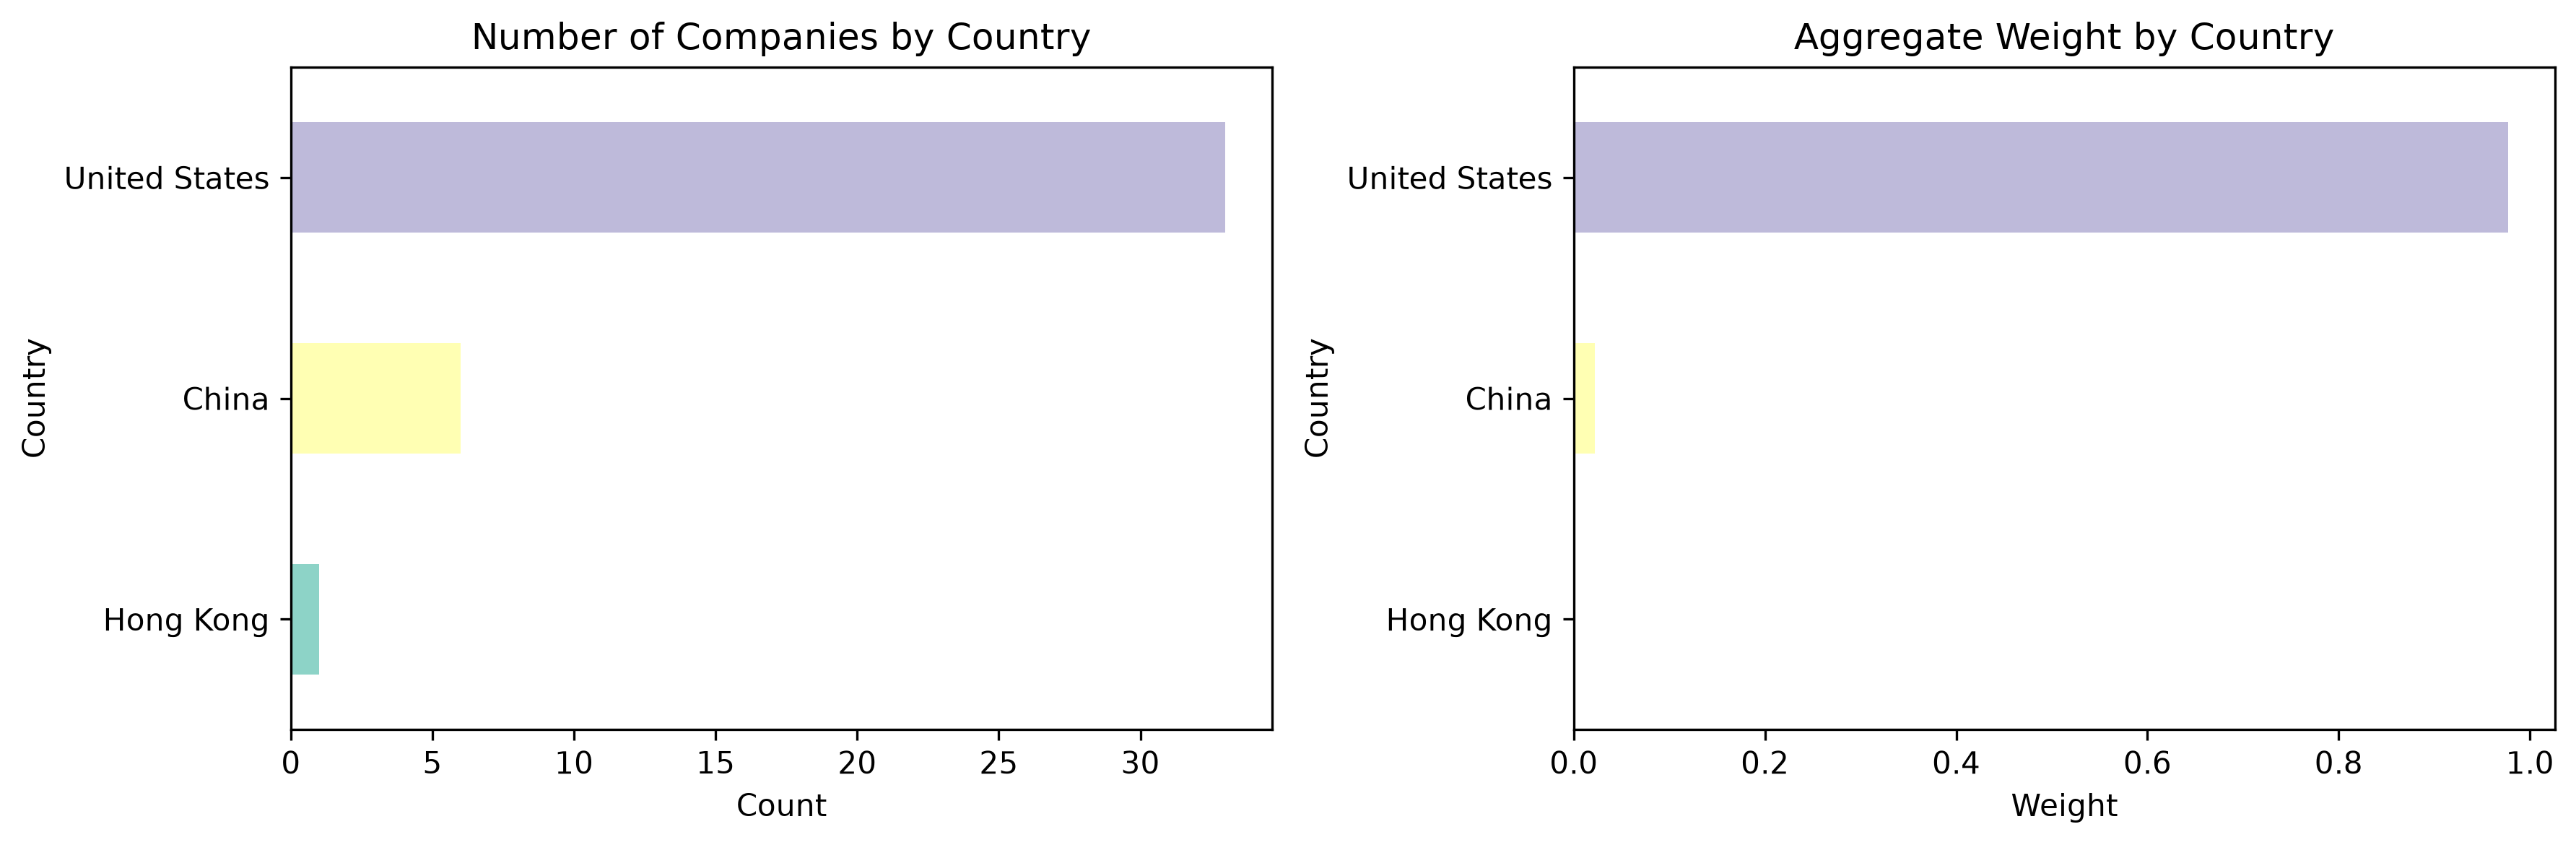

Country
Hong Kong         1
China             6
United States    33
Name: count, dtype: int64

Weight by country:
Country
United States    97.73%
China             2.24%
Hong Kong         0.03%
Name: Weight, dtype: str


In [9]:
import matplotlib.pyplot as plt
from matplotlib import colormaps

set3 = colormaps["Set3"]

country_counts = j_index_constituents["Country"].value_counts().sort_values()
country_weights = j_index_constituents.groupby("Country")["Weight"].sum().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=300)

country_counts.plot(
    kind="barh",
    ax=axes[0],
    color=[set3(i % 12) for i in range(len(country_counts))],
)
axes[0].set_title("Number of Companies by Country")
axes[0].set_xlabel("Count")

country_weights.plot(
    kind="barh",
    ax=axes[1],
    color=[set3(i % 12) for i in range(len(country_weights))],
)
axes[1].set_title("Aggregate Weight by Country")
axes[1].set_xlabel("Weight")

plt.tight_layout()
plt.savefig("img/country_exposure.png", dpi=300, bbox_inches="tight")
plt.show()

print(country_counts)
print("\nWeight by country:")
print(country_weights.sort_values(ascending=False).map("{:.2%}".format))


### Total Market Cap

In [10]:
total_market_cap = j_index_constituents["MarketCap"].sum()

print(f"Total market cap: ${total_market_cap:,.0f}")
print(f"Number of constituents: {len(j_index_constituents)}")
print(f"Average market cap: ${total_market_cap / len(j_index_constituents):,.0f}")
print(
    f"Largest holding: {j_index_constituents.iloc[0]['Symbol']} ({j_index_constituents.iloc[0]['Weight']:.1%})"
)
print(
    f"Smallest holding: {j_index_constituents.iloc[-1]['Symbol']} ({j_index_constituents.iloc[-1]['Weight']:.4%})"
)

Total market cap: $20,340,065,819
Number of constituents: 40
Average market cap: $508,501,645
Largest holding: JKHY (52.6%)
Smallest holding: LBGJ (0.0005%)


### Fundamental Metrics

In [11]:
j_index_list = j_index_constituents.Symbol.to_list()
comma_separated_j_index = ",".join(j_index_list)


In [12]:
j_index_fundamentals = obb.equity.fundamental.metrics(
    comma_separated_j_index, provider="yfinance"
)

display(j_index_fundamentals.head(10))


,symbol,currency,market_cap,pe_ratio,forward_pe,peg_ratio,peg_ratio_ttm,enterprise_to_ebitda,earnings_growth,earnings_growth_quarterly,...,book_value,price_to_book,enterprise_value,overall_risk,audit_risk,board_risk,compensation_risk,shareholder_rights_risk,beta,price_return_1y
0,JKHY,USD,11103106048,21.825420,22.006420,2.08,2.0816,15.708,0.125,0.106,...,29.979,5.212649,1.123759e+10,1.0,1.0,2.0,1.0,5.0,0.553,-0.072104
1,RJET,USD,1013642176,14.337749,NaN,NaN,NaN,5.051,-0.277,-0.166,...,30.208,0.716698,1.907132e+09,NaN,NaN,NaN,NaN,NaN,NaN,0.274691
2,JMSB,USD,340104576,13.930635,11.341177,NaN,NaN,NaN,0.398,0.375,...,19.494,1.236278,2.985860e+08,9.0,3.0,5.0,10.0,7.0,0.420,0.236674
3,JJSF,USD,1482738944,25.670456,18.516394,5.12,NaN,9.437,-0.642,-0.652,...,46.930,1.684743,1.614682e+09,6.0,9.0,8.0,5.0,5.0,0.395,-0.348215
4,BJRI,USD,1434277120,35.671955,24.654247,2.30,2.2997,14.512,-0.113,-0.154,...,18.764,3.593050,1.873022e+09,1.0,2.0,1.0,3.0,1.0,1.318,0.963124
5,JOUT,USD,504094560,NaN,20.478724,1.43,1.4292,15.845,3.045,3.084,...,40.597,1.185432,4.324511e+08,9.0,9.0,9.0,5.0,10.0,0.812,0.193639
6,DJCO,USD,810214656,57.823994,NaN,4.32,NaN,27.244,NaN,NaN,...,252.965,2.324709,3.801340e+08,6.0,10.0,7.0,7.0,1.0,0.840,0.447057
7,DJT,USD,2772307968,NaN,NaN,NaN,NaN,-6.543,NaN,NaN,...,4.524,2.212644,2.723594e+09,10.0,10.0,9.0,9.0,7.0,4.107,-0.398414
8,AIRJ,USD,388067168,NaN,-18.067213,NaN,NaN,-22.647,NaN,NaN,...,3.523,1.521431,3.168951e+08,9.0,10.0,8.0,7.0,8.0,0.861,0.029197
9,JYNT,USD,117464456,91.555550,19.015530,8.83,NaN,39.935,0.438,0.342,...,1.129,7.298494,9.380638e+07,8.0,10.0,7.0,10.0,2.0,1.054,-0.259160


In [13]:
fundamentals = j_index_fundamentals.rename(columns={"symbol": "Symbol"})

fundamentals_cols = [
    "Symbol",
    "market_cap",
    "pe_ratio",
    "forward_pe",
    "price_to_book",
    "enterprise_to_ebitda",
    "gross_margin",
    "profit_margin",
    "return_on_equity",
    "debt_to_equity",
    "beta",
    "price_return_1y",
    "overall_risk",
    "audit_risk",
    "board_risk",
    "compensation_risk",
    "shareholder_rights_risk",
]

fundamentals = fundamentals[[c for c in fundamentals_cols if c in fundamentals.columns]]

j_index_full = j_index_constituents.merge(
    fundamentals, on="Symbol", how="left", suffixes=("", "_fund")
)

j_index_full.head(10)


,Symbol,Company,Sector,MarketCap,Weight,Size,Currency,Country,SIC,SIC_Description,...,profit_margin,return_on_equity,debt_to_equity,beta,price_return_1y,overall_risk,audit_risk,board_risk,compensation_risk,shareholder_rights_risk
0,JKHY,JACK HENRY & ASSOCIATES INC,Technology,10698826752,0.525998,Large Cap,USD,United States,7373,Services-Computer Integrated Systems Design,...,0.20637,0.24892,6.398,0.553,-0.072104,1.0,1.0,2.0,1.0,5.0
1,DJT,Trump Media & Technology Group Corp.,Communication Services,2370724864,0.116554,Mid Cap,USD,United States,7370,"Services-Computer Programming, Data Processing...",...,0.00000,-1.01325,76.765,4.107,-0.398414,10.0,10.0,9.0,9.0,7.0
2,JJSF,J&J SNACK FOODS CORP,Consumer Defensive,1433511168,0.070477,Small Cap,USD,United States,2052,Cookies & Crackers,...,0.03746,0.06412,21.877,0.395,-0.348215,6.0,9.0,8.0,5.0,5.0
3,BJRI,BJs RESTAURANTS INC,Consumer Cyclical,1405191552,0.069085,Small Cap,USD,United States,5812,Retail-Eating Places,...,0.02857,0.10440,109.378,1.318,0.963124,1.0,2.0,1.0,3.0,1.0
4,RJET,REPUBLIC AIRWAYS HOLDINGS INC.,Industrials,809681664,0.039807,Small Cap,USD,United States,4512,"Air Transportation, Scheduled",...,0.03535,0.05450,86.165,NaN,0.274691,NaN,NaN,NaN,NaN,NaN
5,DJCO,DAILY JOURNAL CORP,Technology,792327872,0.038954,Small Cap,USD,United States,2711,Newspapers: Publishing or Publishing & Printing,...,0.14834,0.04087,5.989,0.840,0.447057,6.0,10.0,7.0,7.0,1.0
6,JOUT,JOHNSON OUTDOORS INC,Consumer Cyclical,481731104,0.023684,Small Cap,USD,United States,3949,"Sporting & Athletic Goods, NEC",...,-0.02332,-0.03535,10.978,0.812,0.193639,9.0,9.0,9.0,5.0,10.0
7,JMSB,"John Marshall Bancorp, Inc.",Financial Services,315267072,0.015500,Small Cap,USD,United States,6022,State Commercial Banks,...,0.36527,0.09266,NaN,0.420,0.236674,9.0,3.0,5.0,10.0,7.0
8,AIRJ,AirJoule Technologies Corp.,Industrials,301910464,0.014843,Small Cap,USD,United States,3585,Air-Cond & Warm Air Heatg Equip & Comm & Indl ...,...,0.00000,-0.28838,0.048,0.861,0.029197,9.0,10.0,8.0,7.0,8.0
9,JACK,JACK IN THE BOX INC,Consumer Cyclical,277521120,0.013644,Micro Cap,USD,United States,5812,Retail-Eating Places,...,0.02486,NaN,NaN,1.404,-0.160513,5.0,5.0,8.0,5.0,3.0


In [14]:
from great_tables import GT

display_cols = [
    "Symbol",
    "market_cap",
    "pe_ratio",
    "forward_pe",
    "price_to_book",
    "gross_margin",
    "profit_margin",
    "return_on_equity",
    "debt_to_equity",
    "beta",
    "price_return_1y",
]
display_cols = [c for c in display_cols if c in j_index_full.columns]

fundamentals_display = j_index_full[display_cols].copy()
fundamentals_display["move"] = fundamentals_display["price_return_1y"].apply(
    lambda r: (
        "arrow-trend-up"
        if (r is not None and r == r and r > 0)
        else ("arrow-trend-down" if (r is not None and r == r and r < 0) else "minus")
    )
)

gt_fundamentals = (
    GT(fundamentals_display)
    .fmt_number(columns="market_cap", decimals=0, sep_mark=",")
    .fmt_number(columns=["pe_ratio", "forward_pe", "price_to_book"], decimals=1)
    .fmt_percent(
        columns=["gross_margin", "profit_margin", "price_return_1y"], decimals=1
    )
    .fmt_number(columns=["return_on_equity", "debt_to_equity", "beta"], decimals=2)
    .fmt_icon(
        columns="move",
        fill_color={
            "arrow-trend-up": "green",
            "arrow-trend-down": "red",
            "minus": "grey",
        },
    )
    .cols_merge(columns=["price_return_1y", "move"], pattern="{0} {1}")
    .cols_align(align="center", columns=["Symbol"])
    .cols_label(
        market_cap="Market Cap ($)",
        pe_ratio="P/E",
        forward_pe="Fwd P/E",
        price_to_book="P/B",
        gross_margin="Gross Margin",
        profit_margin="Profit Margin",
        return_on_equity="ROE",
        debt_to_equity="Debt/Equity",
        beta="Beta",
        price_return_1y="1Y Price Return",
    )
    .tab_header(title="J Index Fundamental Metrics")
    .opt_row_striping()
    .tab_options(row_striping_background_color="#f2f2f2")
)

gt_fundamentals.gtsave("img/j_index_fundamentals.png")
gt_fundamentals


GT(_tbl_data=   Symbol   market_cap   pe_ratio  forward_pe  price_to_book  gross_margin  \
0    JKHY  11103106048  21.825420   22.006420       5.212649       0.44057   
1     DJT   2772307968        NaN         NaN       2.212644       0.23927   
2    JJSF   1482738944  25.670456   18.516394       1.684743       0.30305   
3    BJRI   1434277120  35.671955   24.654247       3.593050       0.15534   
4    RJET   1013642176  14.337749         NaN       0.716698       0.34209   
5    DJCO    810214656  57.823994         NaN       2.324709       0.34161   
6    JOUT    504094560        NaN   20.478724       1.185432       0.37455   
7    JMSB    340104576  13.930635   11.341177       1.236278       0.00000   
8    AIRJ    388067168        NaN  -18.067213       1.521431       0.00000   
9    JACK    331499424        NaN    4.820507      -0.359195       0.26994   
10   JDZG     21426800        NaN         NaN       0.020602       0.45352   
11   JRVR    213614272  10.744185    4.167907       0.412058       0.34628   
12   JLHL    132338064  32.473686         NaN      12.798141       0.16081   
13   BOTJ    123351656  10.688976         NaN       1.540950       0.00000   
14   JYNT    117464456  91.555550   19.015530       7.298494       0.80621   
15    ZJK    101629152   9.875001         NaN       2.320117       0.43672   
16    JXG     84259952        NaN         NaN       0.550836       0.12587   
17    JFB     89620688        NaN         NaN       1.381353       0.07975   
18   JRSH     59688448  16.785358    8.867737       0.921549       0.16109   
19   TJGC     53227000        NaN         NaN      34.067280       0.21538   
20     SJ     43312024        NaN         NaN       0.470825       0.17900   
21   JSPR     20224278        NaN   -0.237422       5.023140       0.00000   
22     JL     22005574   7.799866         NaN       1.321713       0.33964   
23    JVA     19409240  12.592592    8.500000       0.668765       0.16518   
24   ZJYL     15181992  10.208421         NaN       0.512173       0.30177   
25   CJMB      8638560        NaN         NaN       5.406361       0.35611   
26   JCTC      9628565        NaN         NaN       0.651727       0.08114   
27    JYD      7053235        NaN         NaN       0.178996       0.03350   
28   YHGJ      8062563        NaN         NaN       1.137703       0.17761   
29   JCSE      7404782   2.820000         NaN       0.484194       0.28454   
30     YJ      6101266        NaN   12.387000       0.044143       0.44412   
31    EJH      4000192   0.001861         NaN       0.012493       0.23005   
32   JUNS      4967083        NaN    1.716667      -1.337662       0.00000   
33   INTJ      4735500        NaN         NaN       0.411294       0.63811   
34    JEM      3588394        NaN         NaN       0.090174       0.19821   
35   JWEL      4110706        NaN         NaN       0.358847       0.06991   
36   JTAI      3213089   0.005259   -1.130000       0.040189      -0.05671   
37   JZXN      1953130        NaN         NaN       0.010453       0.00519   
38   BJDX      1008226        NaN   -3.045000       0.241128       0.00000   
39   LBGJ        53734        NaN         NaN       0.076154       0.29250   

    profit_margin  return_on_equity  debt_to_equity   beta  price_return_1y  \
0         0.20637           0.24892           6.398  0.553        -0.072104   
1         0.00000          -1.01325          76.765  4.107        -0.398414   
2         0.03746           0.06412          21.877  0.395        -0.348215   
3         0.02857           0.10440         109.378  1.318         0.963124   
4         0.03535           0.05450          86.165    NaN         0.274691   
5         0.14834           0.04087           5.989  0.840         0.447057   
6        -0.02332          -0.03535          10.978  0.812         0.193639   
7         0.36527           0.09266             NaN  0.420         0.236674   
8         0.00000          -0.28838           0.048  0.861         0.029197  

## Winners vs Losers

The 40 constituents ranked by 1-year price return (not market cap). Green arrows mark gainers, red arrows mark losers. Each row includes a sparkline of the normalized 1-year price path.

In [15]:
from great_tables import GT

prices = download_index_prices(j_index_constituents, lookback_days=365)

winners_losers = j_index_full[["Symbol", "Company", "Sector", "price_return_1y"]].copy()
winners_losers = winners_losers[winners_losers["price_return_1y"].notna()].copy()


def sparkline_path(ticker):
    series = prices[ticker].astype(float).ffill()

    first = series.dropna()

    if first.empty or first.iloc[0] == 0:
        return None

    normalized = series / first.iloc[0]

    n = 30

    sampled = normalized.iloc[:: max(1, len(normalized) // n)].iloc[:n]

    return ",".join(f"{value:.3f}" for value in sampled)


winners_losers["path"] = winners_losers["Symbol"].apply(sparkline_path)
winners_losers = winners_losers[winners_losers["path"].notna()].copy()

winners_losers["move"] = winners_losers["price_return_1y"].apply(
    lambda r: (
        "arrow-trend-up"
        if (r is not None and r == r and r > 0)
        else ("arrow-trend-down" if (r is not None and r == r and r < 0) else "minus")
    )
)

winners_losers = winners_losers.sort_values(
    "price_return_1y", ascending=False
).reset_index(drop=True)

gt_winners_losers = (
    GT(
        winners_losers[
            ["Symbol", "Company", "Sector", "price_return_1y", "move", "path"]
        ]
    )
    .fmt_percent(columns="price_return_1y", decimals=1)
    .fmt_icon(
        columns="move",
        fill_color={
            "arrow-trend-up": "green",
            "arrow-trend-down": "red",
            "minus": "grey",
        },
    )
    .fmt_nanoplot(columns="path", plot_type="line", plot_height="2.5em", autoscale=True)
    .cols_merge(columns=["price_return_1y", "move"], pattern="{0} {1}")
    .cols_align(align="center", columns=["Symbol"])
    .cols_label(
        Symbol="Symbol",
        Company="Company",
        Sector="Sector",
        price_return_1y="1Y Price Return",
        path="1Y Price Path",
    )
    .tab_header(
        title="J Index Winners vs Losers",
        subtitle="Ranked by 1-year price return",
    )
    .opt_row_striping()
    .tab_options(row_striping_background_color="#f2f2f2")
)

gt_winners_losers.gtsave("img/winners_losers_table.png")
gt_winners_losers


GT(_tbl_data=   Symbol                                Company                  Sector  \
0    BJRI                    BJs RESTAURANTS INC       Consumer Cyclical   
1    BOTJ  BANK OF THE JAMES FINANCIAL GROUP INC      Financial Services   
2    JLHL                     Julong Holding Ltd             Industrials   
3    DJCO                     DAILY JOURNAL CORP              Technology   
4    JRSH             Jerash Holdings (US), Inc.       Consumer Cyclical   
5    JCSE              JE Cleantech Holdings Ltd             Industrials   
6      SJ                  Scienjoy Holding Corp  Communication Services   
7    RJET         REPUBLIC AIRWAYS HOLDINGS INC.             Industrials   
8    JMSB            John Marshall Bancorp, Inc.      Financial Services   
9    JOUT                   JOHNSON OUTDOORS INC       Consumer Cyclical   
10   AIRJ            AirJoule Technologies Corp.             Industrials   
11     JL                       J-Long Group Ltd       Consumer Cyclical   
12   JKHY            JACK HENRY & ASSOCIATES INC              Technology   
13   TJGC                         TJGC GROUP Ltd  Communication Services   
14   JWEL                     Jowell Global Ltd.       Consumer Cyclical   
15    JVA                  COFFEE HOLDING CO INC      Consumer Defensive   
16   JACK                    JACK IN THE BOX INC       Consumer Cyclical   
17    JFB              JFB Construction Holdings             Real Estate   
18   JRVR       James River Group Holdings, Inc.      Financial Services   
19   JYNT                             JOINT Corp              Healthcare   
20   JCTC          JEWETT CAMERON TRADING CO LTD         Basic Materials   
21     YJ                             Yunji Inc.       Consumer Cyclical   
22   JJSF                   J&J SNACK FOODS CORP      Consumer Defensive   
23    DJT   Trump Media & Technology Group Corp.  Communication Services   
24    ZJK               ZJK Industrial Co., Ltd.             Industrials   
25    JXG               JX Luxventure Group Inc.       Consumer Cyclical   
26   YHGJ                 YUNHONG GREEN CTI LTD.       Consumer Cyclical   
27   CJMB                        CALLAN JMB INC.             Industrials   
28   JSPR              Jasper Therapeutics, Inc.              Healthcare   
29   ZJYL         Jin Medical International Ltd.              Healthcare   
30   BJDX              Bluejay Diagnostics, Inc.              Healthcare   
31   INTJ                  Intelligent Group Ltd             Industrials   
32    JYD             Jayud Global Logistics Ltd             Industrials   
33   JUNS            JUPITER NEUROSCIENCES, INC.              Healthcare   
34   JZXN                   Jiuzi Holdings, Inc.       Consumer Cyclical   
35   JTAI                            Jet.AI Inc.              Technology   
36    EJH  E-Home Household Service Holdings Ltd       Consumer Cyclical   
37   JDZG                              JIADE Ltd      Consumer Defensive   
38    JEM               707 Cayman Holdings Ltd.       Consumer Cyclical   
39   LBGJ        Li Bang International Corp Inc.             Industrials   

    price_return_1y              move  \
0          0.963124    arrow-trend-up   
1          0.942529    arrow-trend-up   
2          0.545906    arrow-trend-up   
3          0.447057    arrow-trend-up   
4          0.394817    arrow-trend-up   
5          0.360000    arrow-trend-up   
6          0.293082    arrow-trend-up   
7          0.274691    arrow-trend-up   
8          0.236674    arrow-trend-up   
9          0.193639    arrow-trend-up   
10         0.029197    arrow-trend-up   
11        -0.045685  arrow-trend-down   
12        -0.072104  arrow-trend-down   
13        -0.132013  arrow-trend-down   
14        -0.153047  arrow-trend-down   
15        -0.155556  arrow-trend-down   
16        -0.160513  arrow-trend-down   
17        -0.194000  arrow-trend-down   
18        -0.196780  arrow-trend-down   
19        -0.259160  arrow-trend-down   
20       

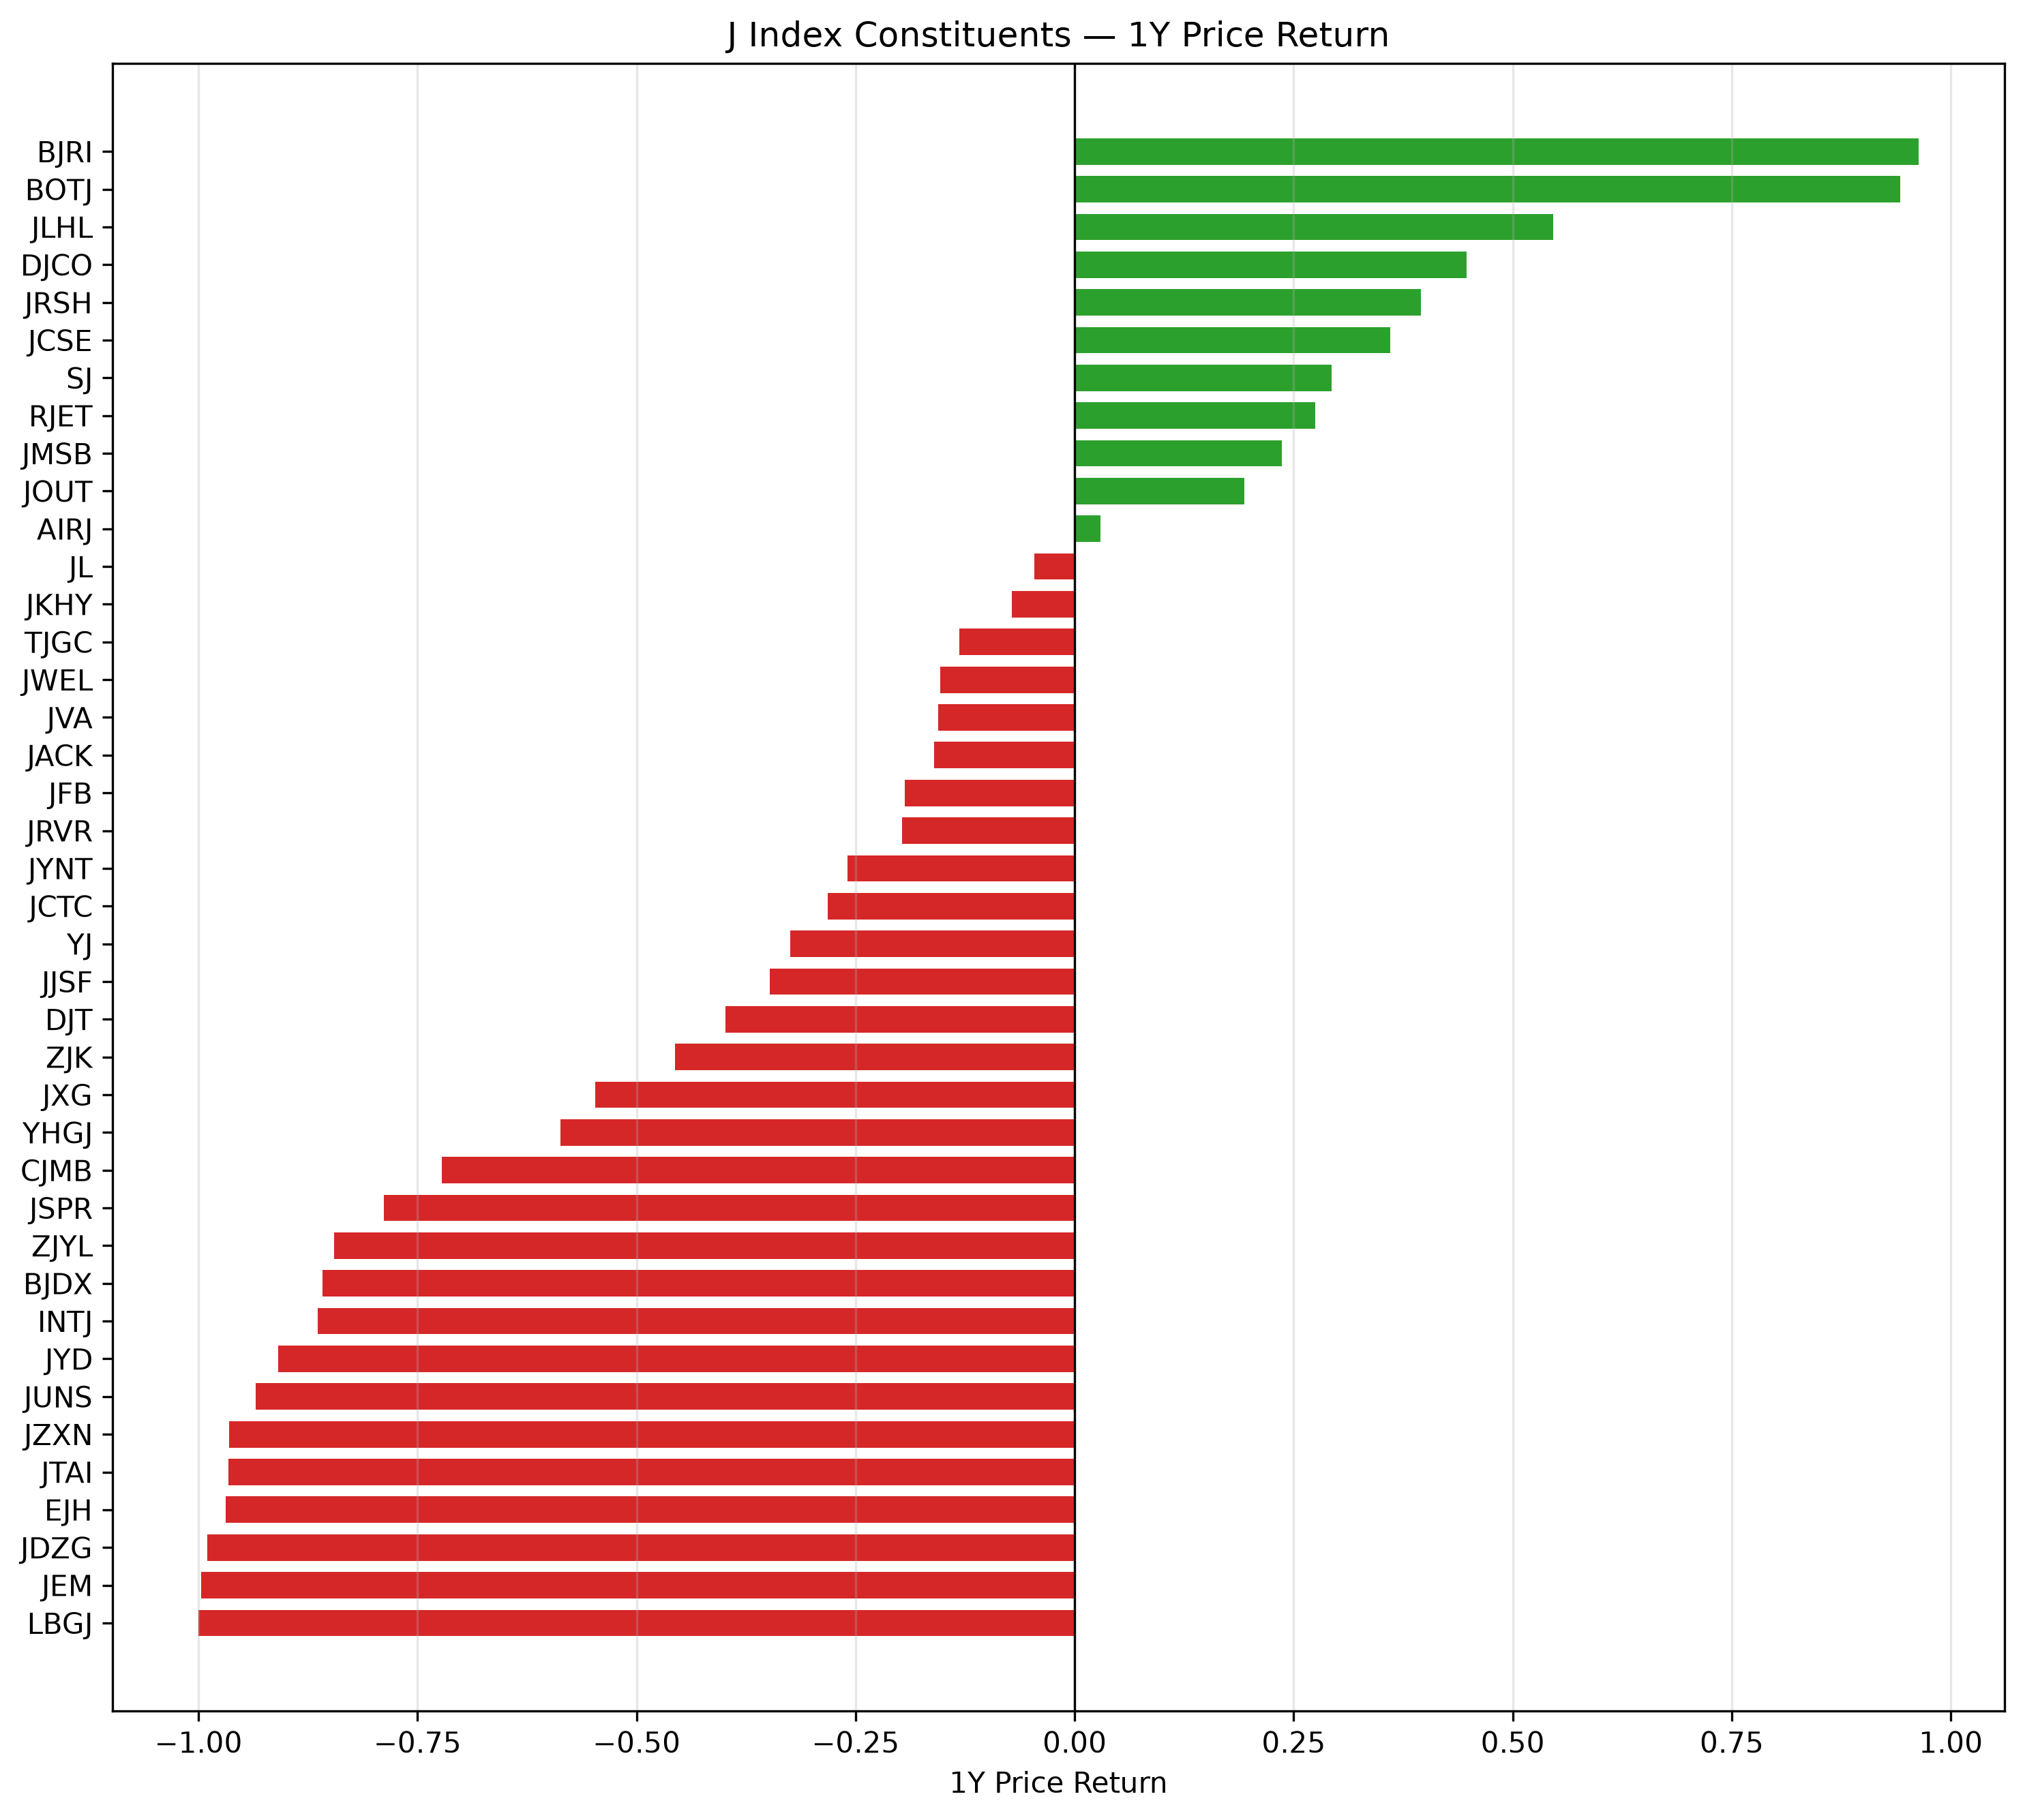

In [16]:
wl_chart = winners_losers.sort_values("price_return_1y")

fig, ax = plt.subplots(figsize=(10, 9), dpi=300)

colors = ["#d62728" if r < 0 else "#2ca02c" for r in wl_chart["price_return_1y"]]

ax.barh(wl_chart["Symbol"], wl_chart["price_return_1y"], color=colors, height=0.7)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("J Index Constituents \u2014 1Y Price Return")
ax.set_xlabel("1Y Price Return")
ax.grid(True, axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("img/winners_losers.png", dpi=300, bbox_inches="tight")
plt.show()


### Valuation Profile

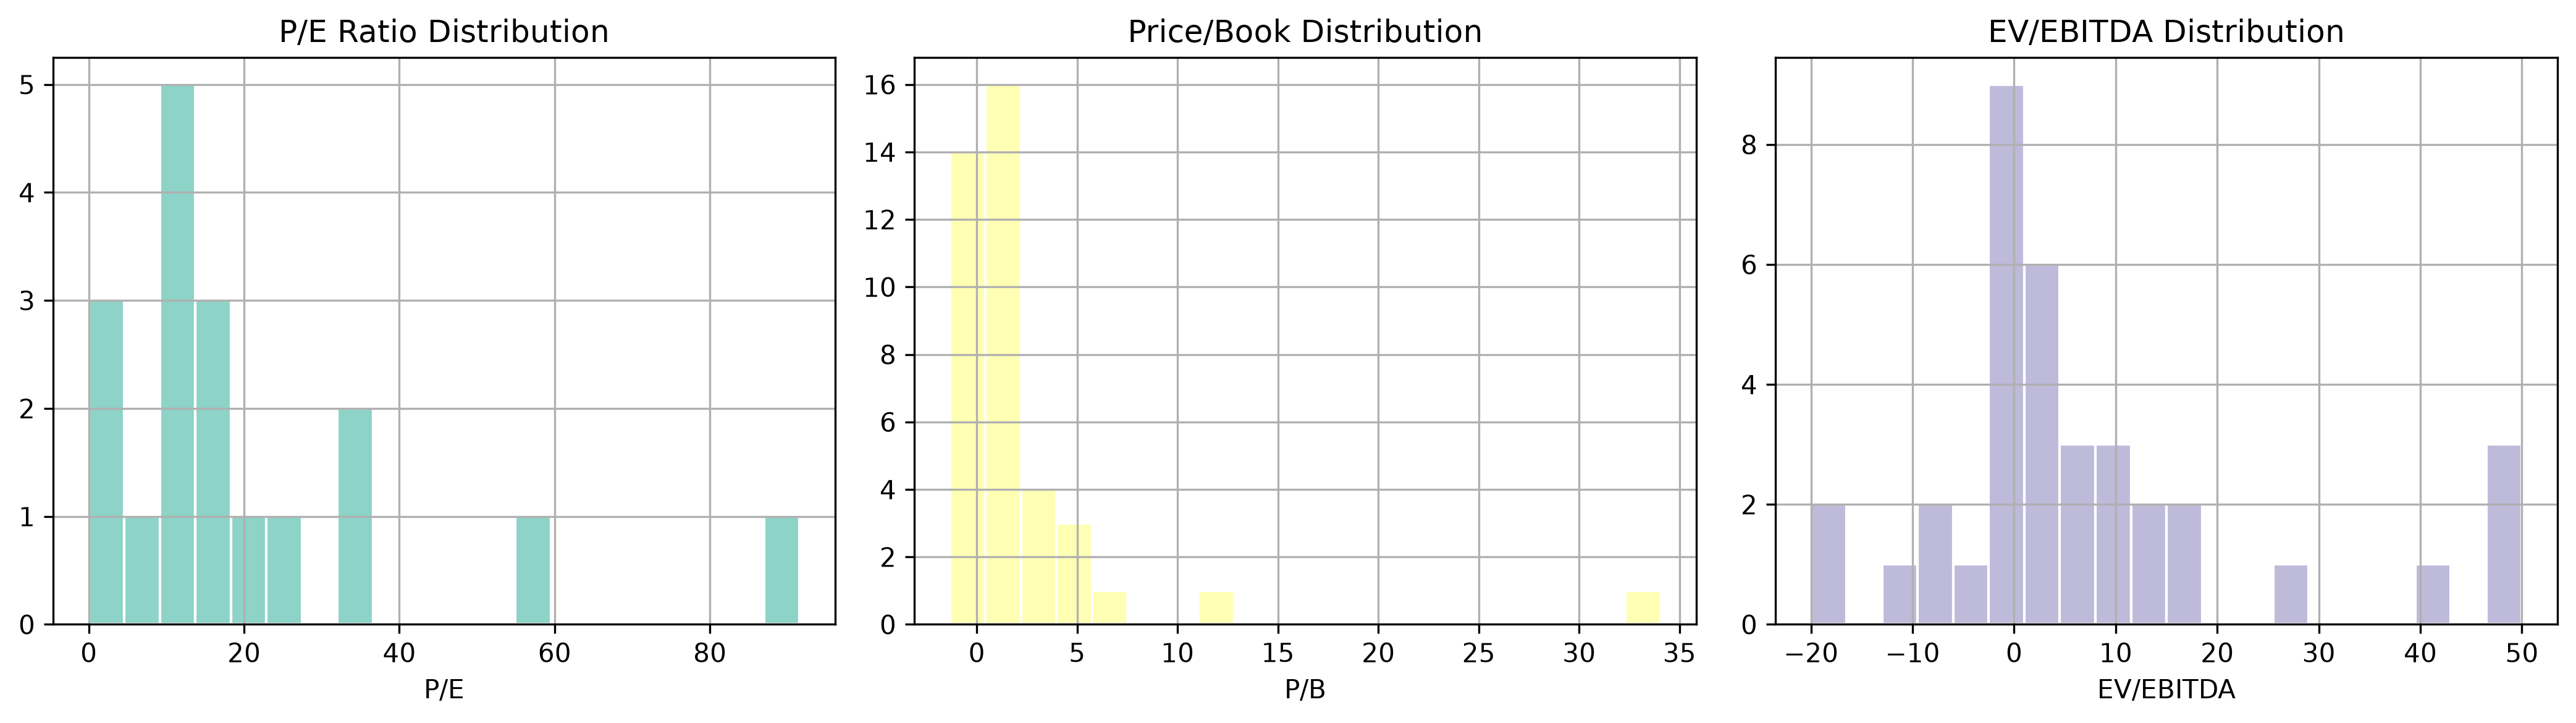

Median P/E: 13.2616135
Median P/B: 0.692731185
Median EV/EBITDA: 2.0535


In [17]:
import matplotlib.pyplot as plt
from matplotlib import colormaps

set3 = colormaps["Set3"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), dpi=300)

j_index_full["pe_ratio"].dropna().hist(
    bins=20, ax=axes[0], color=set3(0), edgecolor="white"
)
axes[0].set_title("P/E Ratio Distribution")
axes[0].set_xlabel("P/E")

j_index_full["price_to_book"].dropna().hist(
    bins=20, ax=axes[1], color=set3(1), edgecolor="white"
)
axes[1].set_title("Price/Book Distribution")
axes[1].set_xlabel("P/B")

j_index_full["enterprise_to_ebitda"].dropna().clip(-20, 50).hist(
    bins=20, ax=axes[2], color=set3(2), edgecolor="white"
)
axes[2].set_title("EV/EBITDA Distribution")
axes[2].set_xlabel("EV/EBITDA")

plt.tight_layout()
plt.savefig("img/valuation_profile.png", dpi=300, bbox_inches="tight")
plt.show()

print("Median P/E:", j_index_full["pe_ratio"].median())
print("Median P/B:", j_index_full["price_to_book"].median())
print("Median EV/EBITDA:", j_index_full["enterprise_to_ebitda"].median())


### Profitability

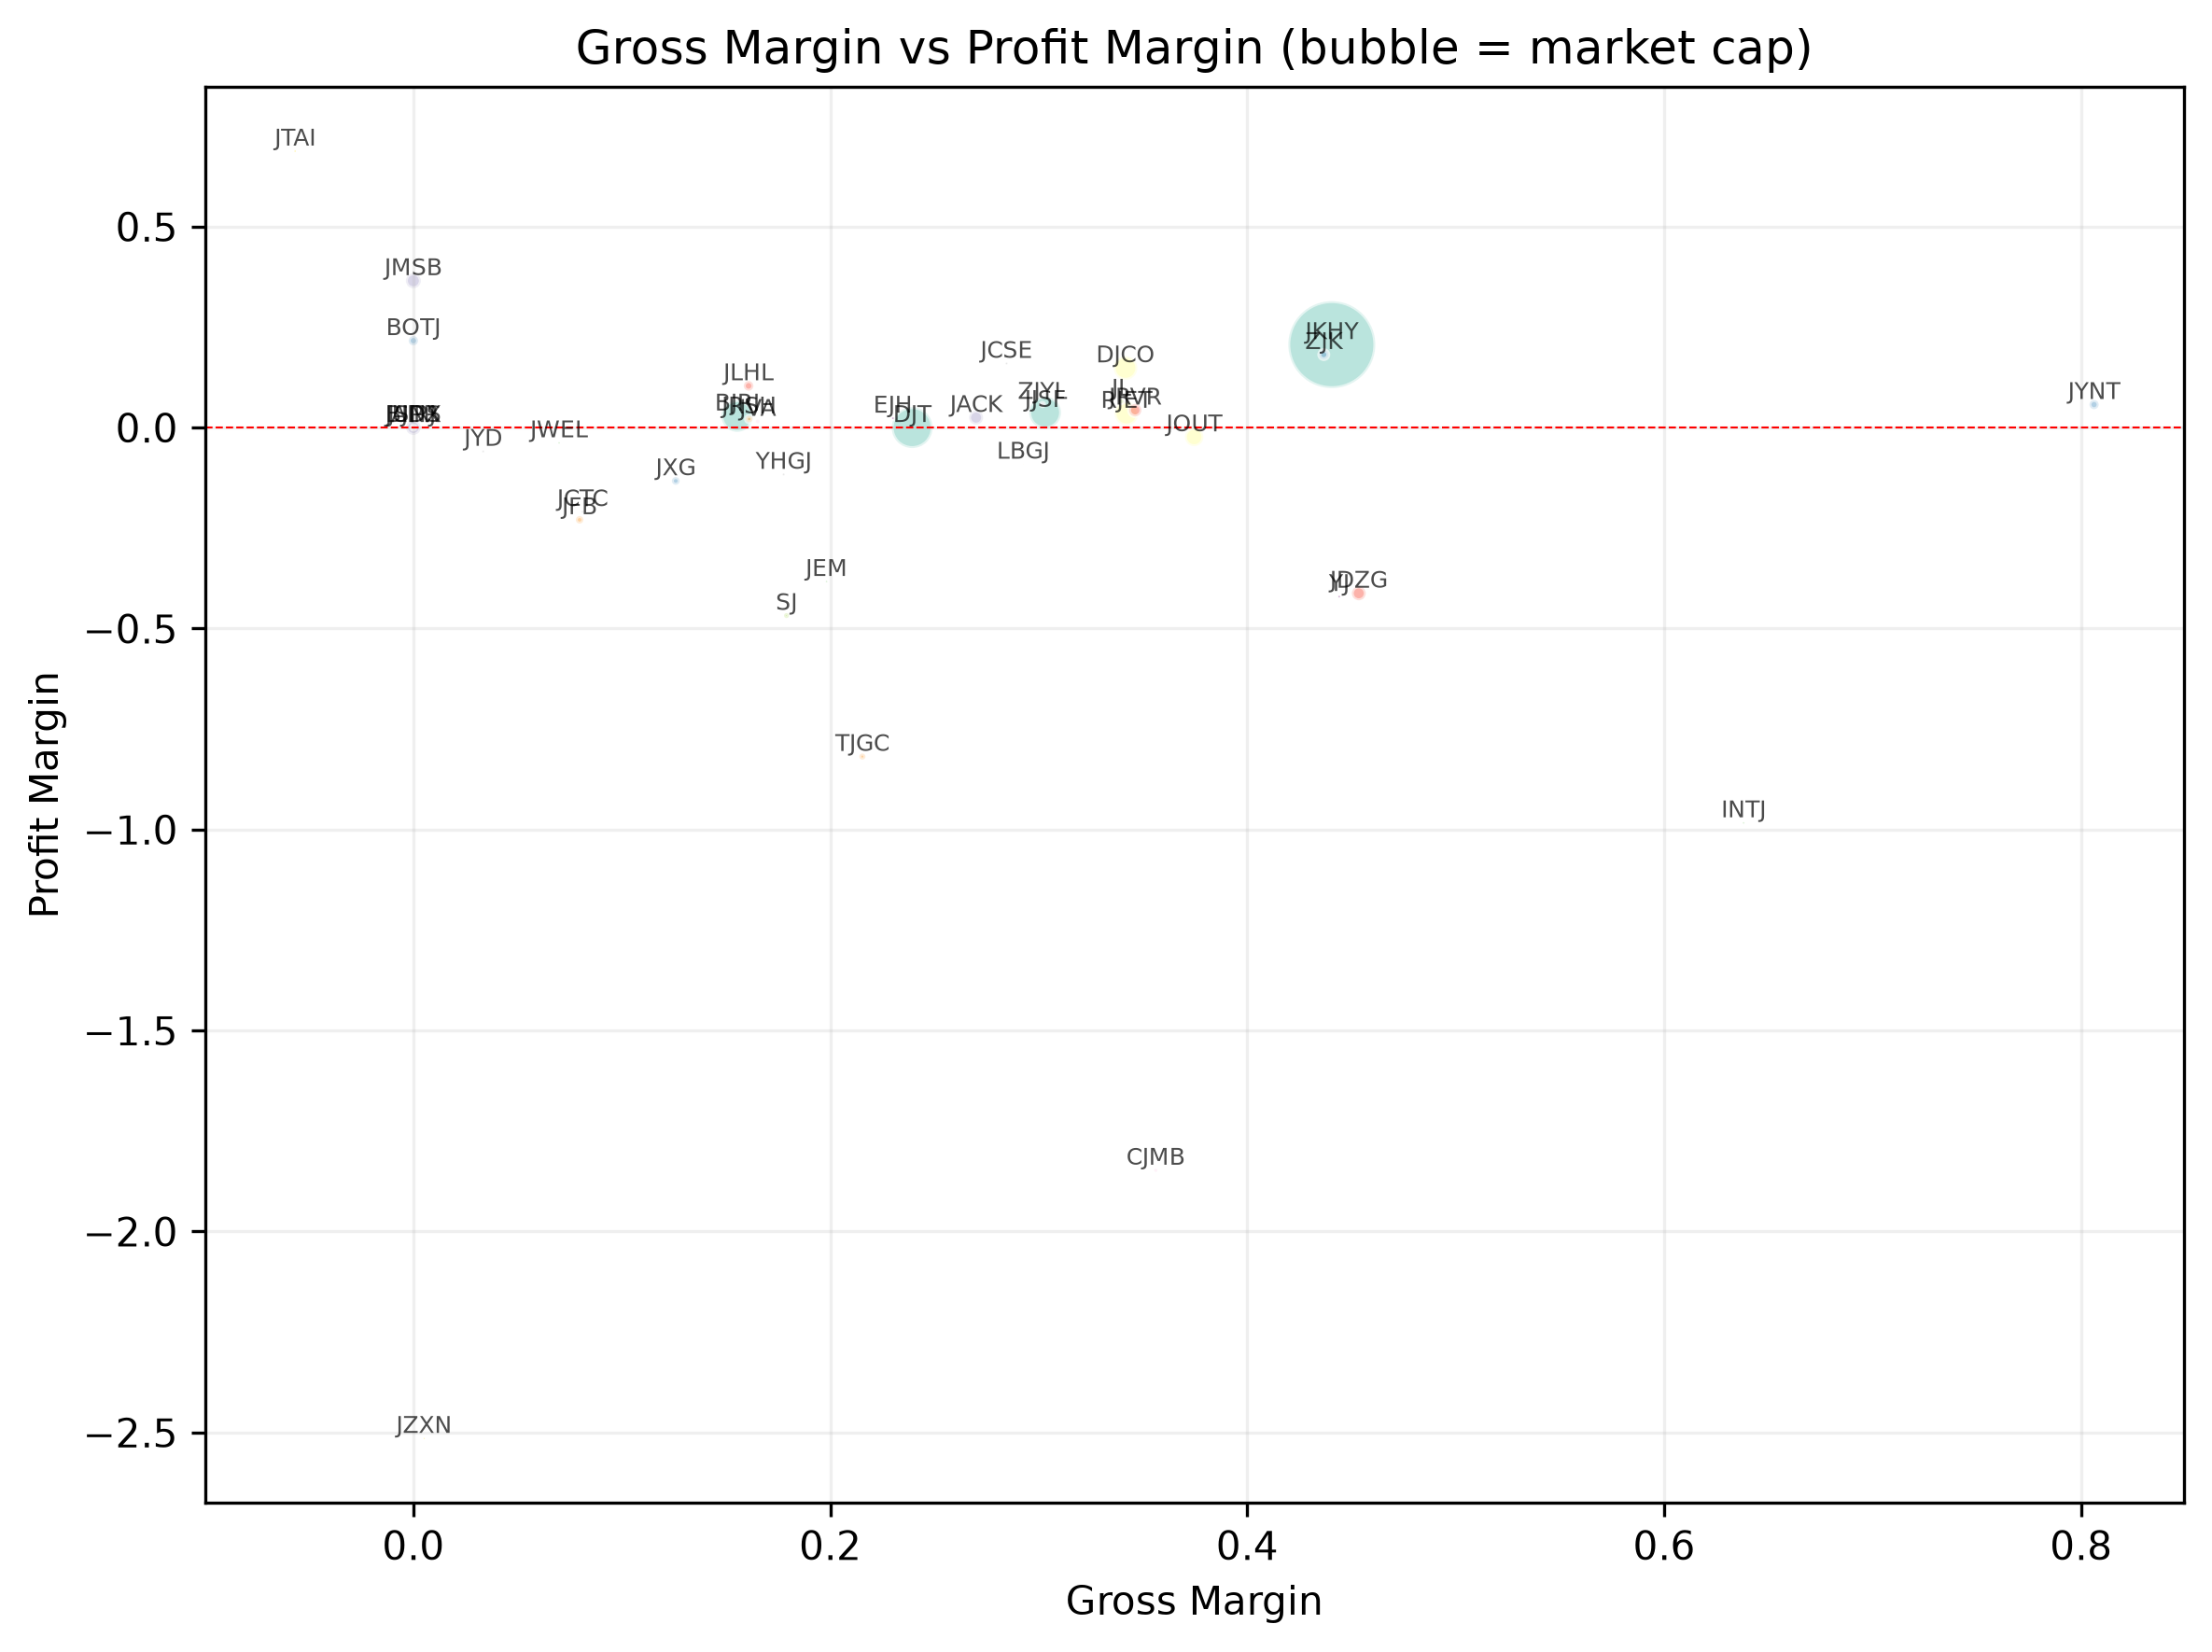

In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

valid = j_index_full.dropna(subset=["gross_margin", "profit_margin", "MarketCap"])
sizes = valid["MarketCap"] / valid["MarketCap"].max() * 500

scatter = ax.scatter(
    valid["gross_margin"],
    valid["profit_margin"],
    s=sizes,
    alpha=0.6,
    c=valid.index,
    cmap="Set3",
    edgecolors="white",
)

for _, row in valid.iterrows():
    ax.annotate(
        row["Symbol"],
        (row["gross_margin"], row["profit_margin"]),
        fontsize=6,
        alpha=0.7,
        ha="center",
        va="bottom",
    )

ax.set_title("Gross Margin vs Profit Margin (bubble = market cap)")
ax.set_xlabel("Gross Margin")
ax.set_ylabel("Profit Margin")
ax.axhline(0, color="red", linewidth=0.5, linestyle="--")
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("img/profitability.png", dpi=300, bbox_inches="tight")
plt.show()


### Risk Profile

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import colormaps

set3 = colormaps["Set3"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=300)

j_index_full["beta"].dropna().hist(
    bins=15, ax=axes[0], color=set3(0), edgecolor="white"
)
axes[0].set_title("Beta Distribution")
axes[0].set_xlabel("Beta")
axes[0].axvline(1.0, color="black", linewidth=1, linestyle="--", label="Market = 1.0")
axes[0].legend()

risk_cols = [
    "overall_risk",
    "audit_risk",
    "board_risk",
    "compensation_risk",
    "shareholder_rights_risk",
]
available_risk = [c for c in risk_cols if c in j_index_full.columns]
risk_means = j_index_full[available_risk].mean().sort_values()
risk_means.plot(
    kind="barh",
    ax=axes[1],
    color=[set3(i) for i in range(len(risk_means))],
)
axes[1].set_title("Average Risk Scores (lower = safer)")
axes[1].set_xlabel("Score")

plt.tight_layout()
plt.savefig("img/risk_profile.png", dpi=300, bbox_inches="tight")
plt.show()

print("Median Beta:", j_index_full["beta"].median())


## J Index Calculation

Now that we have the 40 constituents with their market-cap weights, we can calculate the actual J Index time series.

### Methodology

1. **Download adjusted close prices** for all 40 tickers over the last year
2. **Calculate daily simple returns** for each ticker
3. **Apply fixed weights** — multiply each ticker's return by its market-cap weight
4. **Renormalize daily** — if a ticker has no data on a given day, redistribute its weight to available tickers
5. **Chain into an index** — start at 1000 and compound the weighted portfolio returns

This is a **price return index** (dividends not reinvested) with **fixed weights** (no rebalancing).

In [ ]:
j_index_timeseries = calculate_j_index(j_index_constituents, lookback_days=365)

j_index_timeseries

## J Index Performance

The J Index starts at 1000 and compounds daily weighted returns across all 40 constituents. Weights are based on market capitalization and are renormalized daily for available tickers.

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import colormaps

set3 = colormaps["Set3"]

fig, ax = plt.subplots(figsize=(12, 5), dpi=300)

ax.plot(
    j_index_timeseries["Date"],
    j_index_timeseries["Index"],
    linewidth=1.5,
    color=set3(0),
)
ax.set_title("J Index (Start = 1000)")
ax.set_xlabel("Date")
ax.set_ylabel("Index Level")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("img/j_index_performance.png", dpi=300, bbox_inches="tight")
plt.show()


### Individual Company Performance

Normalized price returns for each constituent (all starting at 1.0), showing relative performance over the period.

In [ ]:
import plotly.graph_objects as go

prices = download_index_prices(j_index_constituents, lookback_days=365)
normalized = prices / prices.iloc[0]

fig = go.Figure()

for ticker in normalized.columns:
    fig.add_trace(
        go.Scatter(
            x=normalized.index,
            y=normalized[ticker],
            name=ticker,
            mode="lines",
            line=dict(width=0.7, color=None),
            opacity=0.6,
            hovertemplate=f"{ticker}: %{{y:.2f}}<extra></extra>",
        )
    )

# Overlay J Index (renormalized)
index_normalized = j_index_timeseries.set_index("Date")["Index"]
index_normalized = index_normalized / index_normalized.iloc[0]
fig.add_trace(
    go.Scatter(
        x=index_normalized.index,
        y=index_normalized.values,
        name="J Index",
        mode="lines",
        line=dict(width=3, color="black"),
        hovertemplate="J Index: %{y:.2f}<extra></extra>",
    )
)

fig.update_layout(
    title="J Index Constituents \u2014 Normalized Price Returns",
    xaxis_title="Date",
    yaxis_title="Normalized Price (Start = 1.0)",
    hovermode="x unified",
    height=600,
    legend=dict(font=dict(size=9)),
)

fig.write_html("img/individual_performance.html")
fig.show()
